In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#pip installs
print("Installing all required packages...")

!pip install -q \
    torch \
    torchvision \
    torchaudio \
    transformers \
    datasets \
    accelerate \
    sentencepiece \
    protobuf \
    scikit-learn \
    pandas \
    numpy \
    matplotlib \
    seaborn

print("All packages installed!")

# Quick verification
import torch
import transformers
import pandas as pd
import numpy as np
import sklearn


print("VERIFICATION")
print("="*60)
print(f"✅ torch: {torch.__version__}")
print(f"✅ transformers: {transformers.__version__}")
print(f"✅ pandas: {pd.__version__}")
print(f"✅ numpy: {np.__version__}")
print(f"✅ scikit-learn: {sklearn.__version__}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not enabled - Enable in Runtime → Change runtime type")


Installing all required packages...
All packages installed!
VERIFICATION
✅ torch: 2.8.0+cu126
✅ transformers: 4.57.1
✅ pandas: 2.2.2
✅ numpy: 2.0.2
✅ scikit-learn: 1.6.1
GPU: Tesla T4


In [ ]:
#imports
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import load_dataset
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla T4


In [74]:
train_df = pd.read_csv('/content/drive/MyDrive/SemEval-task-6-main/csv_files/training_data.csv')
# df_train.head()


In [75]:
test_df = pd.read_csv('/content/drive/MyDrive/SemEval-task-6-main/csv_files/validation_data.csv')
# df_test.head()

In [ ]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

NEGATION_PATTERN = re.compile(
    r"\b(no|not|never|none|nothing|nowhere|neither|nor|cannot|can't|won't|don't|doesn't|didn't|isn't|aren't|wasn't|weren't|without)\b",
    re.IGNORECASE
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [76]:
def feature_engineering(df):
    df = df.copy()

    # Ensure text is string
    df['question'] = df['question'].astype(str)
    df['interview_answer'] = df['interview_answer'].astype(str)

    # Word counts
    df['q_word_count'] = df['question'].str.split().str.len()
    df['a_word_count'] = df['interview_answer'].str.split().str.len()

    # Negation count in answer
    df['a_negation_count'] = df['interview_answer'].apply(
        lambda x: len(NEGATION_PATTERN.findall(x))
    )

    # Cosine similarity between question and answer
    print("Computing embeddings for cosine similarity...")
    q_embeddings = embedding_model.encode(df['question'].tolist(), show_progress_bar=True)
    a_embeddings = embedding_model.encode(df['interview_answer'].tolist(), show_progress_bar=True)

    # Calculate cosine similarity for each pair
    df['qa_cosine_sim'] = [
        cosine_similarity([q_emb], [a_emb])[0][0]
        for q_emb, a_emb in zip(q_embeddings, a_embeddings)
    ]

    return df

In [77]:
train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

Computing embeddings for cosine similarity...


Batches:   0%|          | 0/87 [00:00<?, ?it/s]

Batches:   0%|          | 0/87 [00:00<?, ?it/s]

Computing embeddings for cosine similarity...


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

In [78]:
train_df.head(3)

,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,...,affirmative_questions,index,clarity_label,evasion_label,clarity_label_id,evasion_label_id,q_word_count,a_word_count,a_negation_count,qa_cosine_sim
0,"The President's News Conference in Osaka, Japan","June 29, 2019",Donald J. Trump,https://www.presidency.ucsb.edu/documents/the-...,33,Q. Okay. And another question on the big pictu...,No. I think we're going to be strategic partners.,The question consists of 4 parts: \n1) What do...,Question part: 1) What do you think the U.S. a...,Are we competitors?,...,False,1138,Ambivalent,Implicit,1,4,3,9,1,0.483669
1,The President's News Conference,"September 20, 2007",George W. Bush,https://www.presidency.ucsb.edu/documents/the-...,13,"Q. Alan Greenspan has come out with a book, a ...",My feelings are not hurt. You might have been ...,The question consists of 2 parts:\n\n1. Feelin...,Question part: Feeling of betrayal and critici...,Can you respond to Greenspan's criticism?,...,False,3100,Clear Reply,Explicit,0,0,6,389,7,0.356400
2,The President's News Conference,"December 20, 2007",George W. Bush,https://www.presidency.ucsb.edu/documents/the-...,4,"Q. Mr. President, despite the military success...","Well, first of all, I don't agree with your pr...",The question consists of 2 parts:\n\n1. Benchm...,Question part: Benchmarks for the Iraqi Govern...,What specific actions do you want the Iraqi Go...,...,False,3023,Ambivalent,Deflection,1,5,17,264,9,0.449661


In [79]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df['clarity_label']
)

In [80]:
print(f"\nTrain samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")


Train samples: 2344
Validation samples: 414
Test samples: 690


In [81]:
train_df.to_csv("FE_training_data")

In [82]:
val_df.to_csv("FE_validation_data")

In [83]:
test_df.to_csv("FE_test_data")

## Training

In [132]:
train_df = pd.read_csv("FE_training_data")

In [133]:
val_df = pd.read_csv("FE_validation_data")

In [134]:
test_df = pd.read_csv("FE_test_data")

In [135]:
FEATURE_COLS = ["q_word_count", "a_word_count", "a_negation_count", "qa_cosine_sim"]
FEATURE_DIM = len(FEATURE_COLS)

In [136]:
for df_split in [train_df, val_df, test_df]:
    df_split[FEATURE_COLS] = df_split[FEATURE_COLS].astype(float)

In [137]:
class Config:
    """Configuration for both subtasks"""

    # Model configuration
    MODEL_NAME = "microsoft/deberta-v3-base"
    MAX_LENGTH = 512

    # Subtask 1: Clarity Level (3 classes)
    SUBTASK1_NUM_LABELS = 3

    # Original numeric labels (for model output)
    SUBTASK1_LABELS = {
        'Clear Reply': 0,
        'Ambivalent': 1,
        'Clear Non-Reply': 2
        }

    # Subtask 2: Evasion Level (9 classes)
    SUBTASK2_NUM_LABELS = 9

    SUBTASK2_LABELS = {
        'Explicit': 0,
        'General': 1,
        'Partial/half-answer': 2,
        'Dodging': 3,
        'Implicit': 4,
        'Deflection': 5,
        'Declining to answer': 6,
        'Claims ignorance': 7,
        'Clarification': 8
        }

    # Training configuration
    BATCH_SIZE = 8
    LEARNING_RATE = 2e-5
    NUM_EPOCHS = 5
    WARMUP_STEPS = 500
    WEIGHT_DECAY = 0.01

    # Focal Loss parameters
    FOCAL_ALPHA = 0.25
    FOCAL_GAMMA = 2.0

    # Paths
    OUTPUT_DIR = "./results"
    MODEL_SAVE_PATH = "./saved_models"

config = Config()
print("✓ Configuration loaded successfully!")

✓ Configuration loaded successfully!


In [138]:
# Without FE
# class CLARITYDataset(Dataset):
#     """Custom Dataset for CLARITY task"""

#     def __init__(self, dataframe, tokenizer, max_length, task='subtask1'):
#         self.data = dataframe.reset_index(drop=True)
#         self.tokenizer = tokenizer
#         self.max_length = max_length
#         self.task = task

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         row = self.data.iloc[idx]

#         # Concatenate question and answer
#         question = str(row['question'])
#         interview_answer = str(row['interview_answer'])
#         text = f"Question: {question} [SEP] Answer: {interview_answer}"

#         # Tokenize
#         encoding = self.tokenizer(
#             text,
#             add_special_tokens=True,
#             max_length=self.max_length,
#             padding='max_length',
#             truncation=True,
#             return_attention_mask=True,
#             return_tensors='pt'
#         )

#         # Get label based on task
#         if self.task == 'subtask1':
#             label = int(row['clarity_label_id'])
#         else:
#             label = int(row['evasion_label_id'])

#         return {
#             'input_ids': encoding['input_ids'].flatten(),
#             'attention_mask': encoding['attention_mask'].flatten(),
#             'labels': torch.tensor(label, dtype=torch.long)
#         }

# # Initialize tokenizer
# print("Loading tokenizer...")
# tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
# print(f"Tokenizer loaded: {config.MODEL_NAME}")


In [139]:
# With Features
class CLARITYDataset(Dataset):
    """Custom Dataset for CLARITY task with optional engineered features."""

    def __init__(self, dataframe, tokenizer, max_length, task='subtask1', return_features=False):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.task = task
        self.return_features = return_features

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Concatenate question and answer
        question = str(row['question'])
        interview_answer = str(row['interview_answer'])
        text = f"Question: {question} [SEP] Answer: {interview_answer}"

        # Tokenize
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        # Label
        if self.task == 'subtask1':
            label = int(row['clarity_label_id'])
        else:
            label = int(row['evasion_label_id'])

        item = {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(label, dtype=torch.long),
        }

        # Engineered features
        if self.return_features:
            feats = row[FEATURE_COLS].values.astype("float32")
            item["extra_features"] = torch.tensor(feats, dtype=torch.float32)

        return item


In [140]:
from transformers import AutoModel, AutoConfig

class TransformerWithFeatures(nn.Module):
    def __init__(self, base_model_name, num_labels, feature_dim):
        super().__init__()
        self.config = AutoConfig.from_pretrained(base_model_name)
        self.transformer = AutoModel.from_pretrained(base_model_name, config=self.config)
        hidden_size = self.config.hidden_size

        # classifier on [CLS] + extra features
        self.classifier = nn.Linear(hidden_size + feature_dim, num_labels)

    def forward(self, input_ids, attention_mask, extra_features=None, labels=None):
        outputs = self.transformer(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Take [CLS] / first token representation
        cls_emb = outputs.last_hidden_state[:, 0, :]   # [B, hidden_size]

        if extra_features is not None:
            x = torch.cat([cls_emb, extra_features], dim=1)  # [B, hidden+feat]
        else:
            x = cls_emb

        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.classifier.out_features), labels.view(-1))

        return {"loss": loss, "logits": logits}


In [141]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance
    Reference: https://arxiv.org/abs/1708.02002
    """

    def __init__(self, alpha=0.25, gamma=2.0, num_classes=3):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes

    def forward(self, inputs, targets):
        # Get probabilities
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        p = torch.exp(-ce_loss)

        # Apply focal term
        focal_loss = self.alpha * (1 - p) ** self.gamma * ce_loss

        return focal_loss.mean()

# Test focal loss
focal_loss_fn = FocalLoss(alpha=config.FOCAL_ALPHA, gamma=config.FOCAL_GAMMA, num_classes=3)
print("Focal Loss initialized")


Focal Loss initialized


In [142]:
class FocalLossTrainer(Trainer):
    """Custom Trainer with Focal Loss - Updated for gradient handling"""

    def __init__(self, focal_loss_fn, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss_fn = focal_loss_fn

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Compute loss with focal loss function.
        """
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Compute focal loss
        loss = self.focal_loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

print("✓ FocalLossTrainer fixed")


✓ FocalLossTrainer fixed


In [143]:
def compute_metrics(eval_pred):
    """Compute evaluation metrics"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    # Macro F1 (primary metric for SemEval)
    macro_f1 = f1_score(labels, predictions, average='macro')
    micro_f1 = f1_score(labels, predictions, average='micro')
    weighted_f1 = f1_score(labels, predictions, average='weighted')

    # Per-class F1
    per_class_f1 = f1_score(labels, predictions, average=None)

    metrics = {
        'macro_f1': macro_f1,
        'micro_f1': micro_f1,
        'weighted_f1': weighted_f1,
    }

    # Add per-class metrics
    for idx, f1 in enumerate(per_class_f1):
        metrics[f'class_{idx}_f1'] = f1

    return metrics

print("Metrics function ready")


Metrics function ready


In [144]:
# Clear GPU memory before training
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

# Check available memory
if torch.cuda.is_available():
    print(f"GPU Memory before training:")
    print(f"  Allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    print(f"  Reserved: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")
    print(f"  Free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9:.2f} GB")

GPU Memory before training:
  Allocated: 4.56 GB
  Reserved: 5.23 GB
  Free: 11.27 GB


In [145]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

def train_model(train_df, val_df, task='subtask1', model_save_path=None):
    """Train with class weighting to handle imbalance"""

    import gc

    print(f"\n{'='*60}")
    print(f"Training Model for {task.upper()} WITH CLASS WEIGHTS")
    print(f"{'='*60}")

    # Clear cache
    torch.cuda.empty_cache()
    gc.collect()

    # Get label column and num_labels
    if task == 'subtask1':
        label_col = 'clarity_label_id'
        num_labels = config.SUBTASK1_NUM_LABELS
    else:
        label_col = 'evasion_label_id'
        num_labels = config.SUBTASK2_NUM_LABELS

    # Compute class weights from train_df
    unique_classes = sorted(train_df[label_col].unique())
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array(unique_classes),
        y=train_df[label_col]
    )

    # Full weight tensor
    weights_full = torch.ones(num_labels, dtype=torch.float32)
    for cls, weight in zip(unique_classes, class_weights):
        weights_full[int(cls)] = float(weight)

    weights_full = weights_full.to(device)

    print(f"\n⚖️ Class weights:")
    for i, weight in enumerate(weights_full):
        print(f"   Class {i}: {weight:.3f}")

    # Load model
    print(f"\nLoading model: {config.MODEL_NAME}")
    # model = AutoModelForSequenceClassification.from_pretrained(
    #     config.MODEL_NAME,
    #     num_labels=num_labels,
    #     problem_type="single_label_classification"
    # )
    # model.to(device)

    # >>> Wrap your existing DataFrames in CLARITYDataset <<<
    #Without FE
    # print("Creating datasets from DataFrames...")
    # train_dataset = CLARITYDataset(train_df, tokenizer, config.MAX_LENGTH, task=task)
    # val_dataset   = CLARITYDataset(val_df,   tokenizer, config.MAX_LENGTH, task=task)
    # print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")


    model = TransformerWithFeatures(
    base_model_name=config.MODEL_NAME,
    num_labels=num_labels,
    feature_dim=FEATURE_DIM).to(device)

    #With FE
    print("Creating datasets from DataFrames...")
    train_dataset = CLARITYDataset(train_df, tokenizer, config.MAX_LENGTH, task='subtask1', return_features=True)
    val_dataset   = CLARITYDataset(val_df,   tokenizer, config.MAX_LENGTH, task='subtask1', return_features=True)
    print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")


    # Custom Trainer with weighted loss
    # class WeightedTrainer(Trainer):
    #     def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
    #         labels = inputs.pop("labels")
    #         outputs = model(**inputs)
    #         logits = outputs.logits

    #         loss_fct = nn.CrossEntropyLoss(weight=weights_full)
    #         loss = loss_fct(logits.view(-1, num_labels), labels.view(-1))
    #         return (loss, outputs) if return_outputs else loss


    class WeightedTrainer(Trainer):
      def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        extra_features = inputs.pop("extra_features", None)  # [B, F] or None
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            extra_features=extra_features,
            labels=labels
            )
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss


    output_dir = f"{config.OUTPUT_DIR}/{task}_weighted"

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=config.NUM_EPOCHS,
        per_device_train_batch_size=config.BATCH_SIZE,
        per_device_eval_batch_size=config.BATCH_SIZE,
        learning_rate=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY,
        warmup_steps=config.WARMUP_STEPS,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=50,
        save_total_limit=1,
        seed=SEED,
        fp16=True,
        report_to="none",
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,   # now a Dataset, not df
        eval_dataset=val_dataset,      # now a Dataset, not df
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    print("\n🚀 Training with class weights...")
    train_result = trainer.train()

    # Save
    if model_save_path:
        trainer.save_model(model_save_path)
        tokenizer.save_pretrained(model_save_path)

    # Evaluate
    print("\nEvaluating...")
    eval_results = trainer.evaluate()

    print("\n✅ Results:")
    print(f"   Macro F1: {eval_results['eval_macro_f1']:.4f}")
    print(f"   Weighted F1: {eval_results['eval_weighted_f1']:.4f}")

    # Prediction diversity on validation Dataset
    predictions = trainer.predict(val_dataset)
    preds = np.argmax(predictions.predictions, axis=1)
    unique_preds = len(np.unique(preds))
    print(f"   Predicting {unique_preds} different classes")

    torch.cuda.empty_cache()
    gc.collect()

    return trainer, model, eval_results

print("✓ Weighted training function ready")


✓ Weighted training function ready


In [146]:
# Train Subtask 1
print("="*80)
print("TRAINING SUBTASK 1: CLARITY LEVEL CLASSIFICATION")
print("="*80)


trainer_subtask1, model_subtask1, results_subtask1 = train_model(
    train_df=train_df,
    val_df=val_df,
    task='subtask1',
    model_save_path=f"{config.MODEL_SAVE_PATH}/FE/subtask1"
)

TRAINING SUBTASK 1: CLARITY LEVEL CLASSIFICATION

Training Model for SUBTASK1 WITH CLASS WEIGHTS

⚖️ Class weights:
   Class 0: 1.093
   Class 1: 0.563
   Class 2: 3.229

Loading model: microsoft/deberta-v3-base
Creating datasets from DataFrames...
Train: 2344, Val: 414

🚀 Training with class weights...


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Weighted F1,Class 0 F1,Class 1 F1,Class 2 F1
1,1.905400,2.270352,0.292396,0.485507,0.446031,0.254237,0.622951,0.000000
2,1.290900,1.739501,0.291528,0.454106,0.431231,0.300366,0.574219,0.000000
3,1.235300,1.644330,0.433052,0.507246,0.505686,0.430464,0.582979,0.285714
4,1.010900,1.280027,0.478260,0.596618,0.582207,0.475806,0.692308,0.266667
5,0.999200,1.236586,0.541721,0.630435,0.623634,0.564103,0.700405,0.360656



Evaluating...



✅ Results:
   Macro F1: 0.5417
   Weighted F1: 0.6236
   Predicting 3 different classes


In [147]:
print("="*80)
print("TRAINING SUBTASK 2: EVASION LEVEL CLASSIFICATION")
print("="*80)

trainer_subtask2, model_subtask2, results_subtask2 = train_model(
    train_df=train_df,          # evasion training dataframe
    val_df=val_df,              # evasion validation dataframe
    task='subtask2',
    model_save_path=f"{config.MODEL_SAVE_PATH}/FE/subtask2"
)



TRAINING SUBTASK 2: EVASION LEVEL CLASSIFICATION

Training Model for SUBTASK2 WITH CLASS WEIGHTS

⚖️ Class weights:
   Class 0: 0.364
   Class 1: 0.987
   Class 2: 4.914
   Class 3: 0.548
   Class 4: 0.764
   Class 5: 1.025
   Class 6: 2.771
   Class 7: 3.101
   Class 8: 4.069

Loading model: microsoft/deberta-v3-base
Creating datasets from DataFrames...
Train: 2344, Val: 414

🚀 Training with class weights...


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Weighted F1,Class 0 F1,Class 1 F1,Class 2 F1,Class 3 F1,Class 4 F1
1,2.704200,2.557726,0.165021,0.475845,0.440684,0.165605,0.659498,0.000000,0.000000,0.000000
2,1.448800,1.553742,0.227444,0.478261,0.455187,0.289474,0.620301,0.000000,0.000000,No Log
3,1.169900,1.085031,0.428420,0.649758,0.638720,0.495327,0.740741,0.477612,0.000000,No Log
4,0.962700,1.151748,0.404821,0.640097,0.604467,0.361446,0.745645,0.512195,0.000000,No Log
5,0.772600,0.989539,0.434413,0.654589,0.646763,0.523364,0.740602,0.473684,0.000000,No Log



Evaluating...



✅ Results:
   Macro F1: 0.4344
   Weighted F1: 0.6468
   Predicting 4 different classes


In [151]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_and_visualize(trainer, model, test_df, task):
    """Evaluation with ids only (no label name mapping)."""
    print(f"\n{'='*60}")
    print(f"Detailed Evaluation for {task.upper()}")
    print(f"{'='*60}")

    # Build test dataset
    # test_dataset = CLARITYDataset(test_df, tokenizer, config.MAX_LENGTH, task=task)
    test_dataset = CLARITYDataset(test_df, tokenizer, config.MAX_LENGTH, task=task, return_features=True)

    # Get predictions
    predictions = trainer.predict(test_dataset)
    pred_labels = np.argmax(predictions.predictions, axis=1)
    true_labels = predictions.label_ids

    # Classification report (uses label ids)
    print("\nClassification Report (label ids):")
    print(classification_report(true_labels, pred_labels, digits=4))

    # Confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)
    labels = sorted(np.unique(true_labels))

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f'Confusion Matrix - {task.upper()}', fontsize=16, fontweight='bold')
    plt.ylabel('True Label (id)', fontsize=12)
    plt.xlabel('Predicted Label (id)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{task}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Per-class F1 (indexed by label id)
    per_class_f1 = f1_score(true_labels, pred_labels, average=None, labels=labels)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(labels)), per_class_f1, color='steelblue', alpha=0.7)
    plt.xlabel('Class ID', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.title(f'Per-Class F1 Scores - {task.upper()}', fontsize=16, fontweight='bold')
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)

    for i, (bar, score) in enumerate(zip(bars, per_class_f1)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{score:.3f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'per_class_f1_{task}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Aggregate metrics
    metrics = {
        'macro_f1': f1_score(true_labels, pred_labels, average='macro'),
        'micro_f1': f1_score(true_labels, pred_labels, average='micro'),
        'weighted_f1': f1_score(true_labels, pred_labels, average='weighted'),
        'per_class_f1': per_class_f1,
        'confusion_matrix': cm
    }

    return metrics, pred_labels



Detailed Evaluation for SUBTASK1



Classification Report (label ids):
              precision    recall  f1-score   support

           0     0.5238    0.6111    0.5641       126
           1     0.6948    0.7061    0.7004       245
           2     0.6111    0.2558    0.3607        43

    accuracy                         0.6304       414
   macro avg     0.6099    0.5243    0.5417       414
weighted avg     0.6341    0.6304    0.6236       414



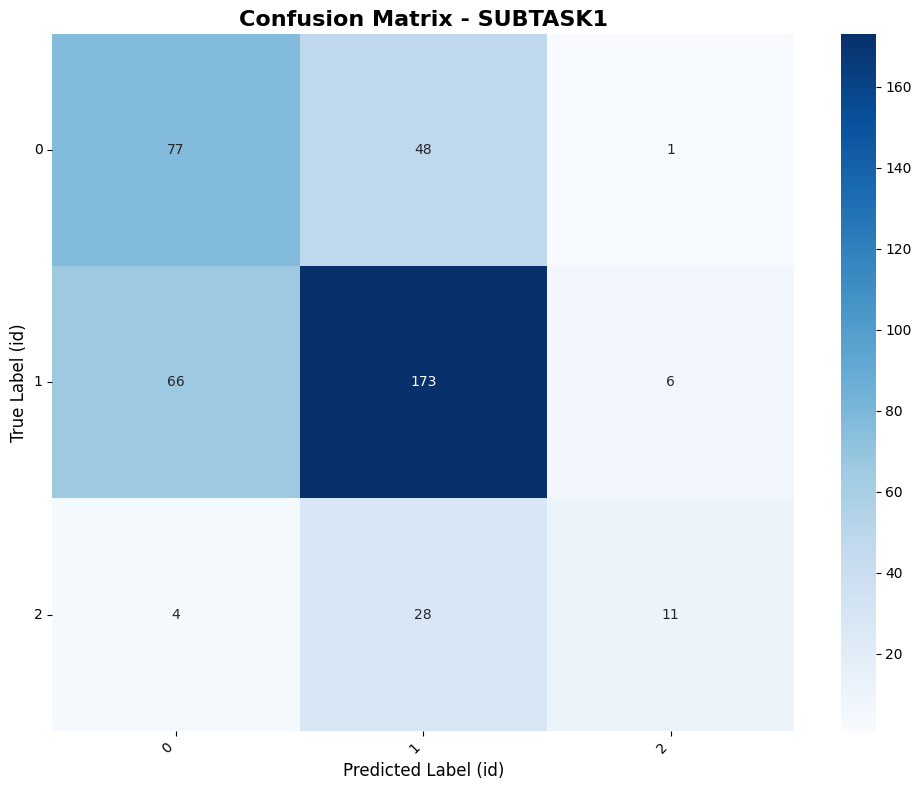

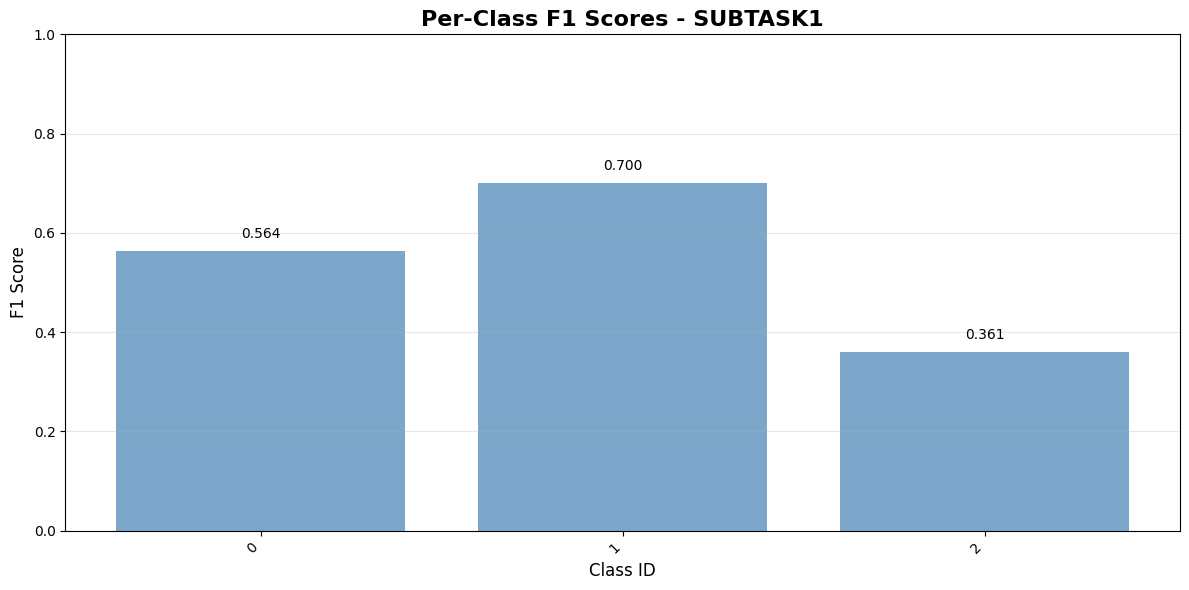

In [155]:
# Evaluate Subtask 1 on test set
metrics_subtask1, preds_subtask1 = evaluate_and_visualize(
    trainer_subtask1,
    model_subtask1,
    val_df,
    task='subtask1'
)



Detailed Evaluation for SUBTASK2



Classification Report (label ids):
              precision    recall  f1-score   support

           0     0.5517    0.4550    0.4987       211
           1     0.1315    0.7532    0.2239        77
           2     0.0286    0.1250    0.0465        16
           3     0.0000    0.0000    0.0000       141
           4     0.0000    0.0000    0.0000        98
           5     0.2000    0.0132    0.0247        76
           6     0.0000    0.0000    0.0000        29
           7     0.0000    0.0000    0.0000        24
           8     0.0000    0.0000    0.0000        18

    accuracy                         0.2275       690
   macro avg     0.1013    0.1496    0.0882       690
weighted avg     0.2061    0.2275    0.1813       690



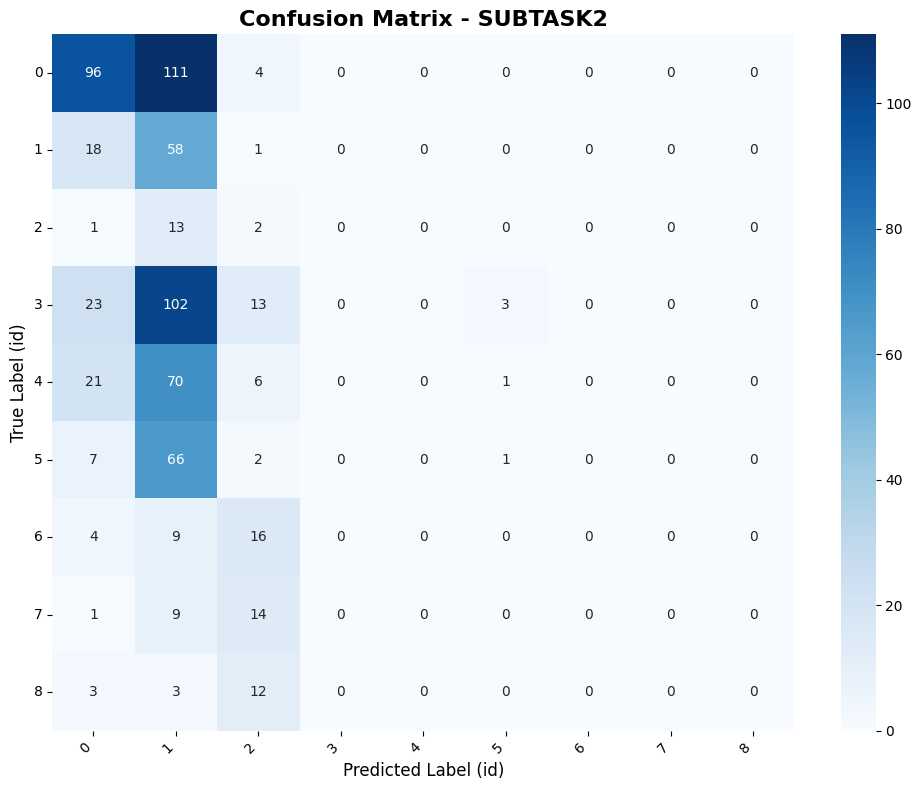

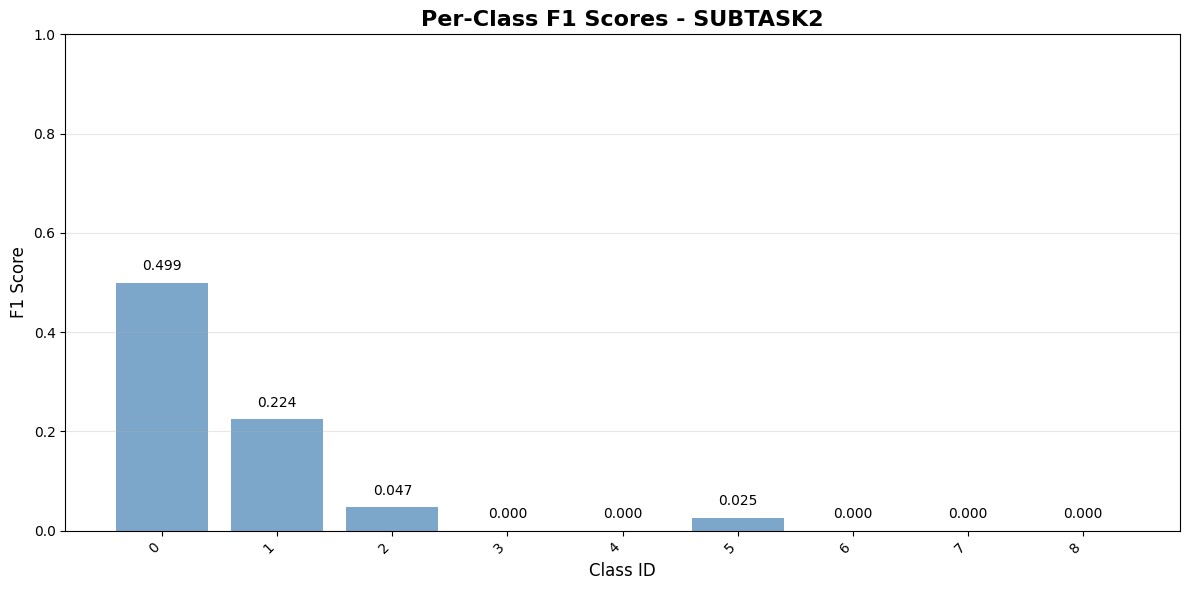

In [153]:
# Evaluate Subtask 2 with only present classes
# print("\n" + "="*80)
# print("EVALUATING SUBTASK 2 (EVASION)")
# print("="*80)

# # Get present classes in validation
# present_classes = sorted(dataset['validation']['evasion_label'].unique())
# print(f"Evaluating on {len(present_classes)} classes: {present_classes}")

# # Create label dict for only present classes
# present_label_dict = {i: config.SUBTASK2_LABELS[i] for i in present_classes}

# metrics_subtask2, preds_subtask2 = evaluate_and_visualize(
#     trainer_subtask2,
#     model_subtask2,
#     dataset['validation'],
#     'subtask2',
#     present_label_dict  # Only use present classes
# )


metrics_subtask2, preds_subtask2 = evaluate_and_visualize(
    trainer_subtask2,
    model_subtask2,
    test_df,
    task='subtask2'
)


In [154]:
# Create comprehensive results summary
def create_results_summary(metrics_subtask1, metrics_subtask2):
    """Create a summary of results for both subtasks"""

    summary = {
        'Model': 'DeBERTa-v3-base',
        'Subtask 1 - Macro F1': f"{metrics_subtask1['macro_f1']:.4f}",
        'Subtask 1 - Weighted F1': f"{metrics_subtask1['weighted_f1']:.4f}",
        'Subtask 2 - Macro F1': f"{metrics_subtask2['macro_f1']:.4f}",
        'Subtask 2 - Weighted F1': f"{metrics_subtask2['weighted_f1']:.4f}",
    }

    print("\n" + "="*80)
    print("FINAL RESULTS SUMMARY")
    print("="*80)
    for key, value in summary.items():
        print(f"{key}: {value}")
    print("="*80)

    # Save to file
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv('results_summary.csv', index=False)
    print("\nResults summary saved to results_summary.csv")

    return summary_df

results_summary = create_results_summary(metrics_subtask1, metrics_subtask2)
results_summary



FINAL RESULTS SUMMARY
Model: DeBERTa-v3-base
Subtask 1 - Macro F1: 0.5611
Subtask 1 - Weighted F1: 0.6021
Subtask 2 - Macro F1: 0.0882
Subtask 2 - Weighted F1: 0.1813

Results summary saved to results_summary.csv


,Model,Subtask 1 - Macro F1,Subtask 1 - Weighted F1,Subtask 2 - Macro F1,Subtask 2 - Weighted F1
0,DeBERTa-v3-base,0.5611,0.6021,0.0882,0.1813
